# 📈 Time Series Analysis — Stock Prices
**Task 2 | Tools:** Python · pandas · matplotlib · statsmodels · seaborn

---
### Objectives:
1. Load and explore a real stock price dataset
2. Plot the time series and identify patterns
3. Decompose the series into **Trend**, **Seasonality**, and **Residuals**
4. Apply **Moving Average Smoothing** and visualize results

---
## 1️⃣ Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

## 2️⃣ Load & Read the Dataset

In [ ]:
df = pd.read_csv("2) Stock Prices Data Set.csv" , parse_dates=['date'],index_col='date')

### 🔍 Preview — First 5 Rows

In [ ]:
df.head(5)

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAL,25.0700,25.8200,25.0600,25.3600,8998943
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-02,AAP,110.3600,111.8800,109.2900,109.7400,542711
2014-01-02,ABBV,52.1200,52.3300,51.5200,51.9800,4569061
2014-01-02,ABC,70.1100,70.2300,69.4800,69.8900,1148391


### 📋 Dataset Info (dtypes & non-null counts)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 497472 entries, 2014-01-02 to 2017-12-29
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   open    497461 non-null  float64
 2   high    497464 non-null  float64
 3   low     497464 non-null  float64
 4   close   497472 non-null  float64
 5   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 26.6+ MB


### 📊 Descriptive Statistics

In [ ]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


## 3️⃣ Data Preprocessing
### Sort by Date

In [ ]:
df = df.sort_values('date')

### ✅ Preview After Sorting

In [ ]:
df.head(5)

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAL,25.07,25.82,25.060,25.36,8998943
2014-01-02,NVDA,15.92,15.98,15.720,15.86,6502296
2014-01-02,NUE,53.29,53.38,52.510,52.73,1611326
2014-01-02,NTRS,61.76,61.95,60.665,60.89,1011050
2014-01-02,NTAP,41.01,41.01,40.415,40.42,2427140


### 🔎 Check for Missing Values

In [ ]:
df.isna().sum()

,0
symbol,0
open,11
high,8
low,8
close,0
volume,0


### 🗑️ Drop Missing Values

In [ ]:
df.dropna(inplace=True)

## 4️⃣ Explore Available Symbols

In [ ]:
print("Available symbols:", df['symbol'].unique())


Available symbols: ['AAL' 'NVDA' 'NUE' 'NTRS' 'NTAP' 'NSC' 'NRG' 'NOV' 'NOC' 'NLSN' 'NKE'
 'NI' 'NFX' 'NWL' 'NFLX' 'NEE' 'NDAQ' 'NCLH' 'NBL' 'M' 'MYL' 'MU' 'MTD'
 'MTB' 'MS' 'MSI' 'MSFT' 'NEM' 'MRO' 'NWSA' 'OKE' 'PNW' 'PNR' 'PNC' 'PM'
 'PLD' 'PKI' 'PKG' 'PH' 'PHM' 'PG' 'PGR' 'PFG' 'NWS' 'PFE' 'PEG' 'PDCO'
 'PCLN' 'PCG' 'PCAR' 'PBCT' 'PAYX' 'O' 'OXY' 'ORLY' 'ORCL' 'OMC' 'PEP'
 'MRK' 'MPC' 'MO' 'LLY' 'LLL' 'LKQ' 'LH' 'LEN' 'LEG' 'LB' 'K' 'KSU' 'KSS'
 'KR' 'KO' 'LMT' 'KORS' 'KMI' 'KMB' 'KLAC' 'KIM' 'KEY' 'JWN' 'JPM' 'JNPR'
 'JNJ' 'JEC' 'JCI' 'JBHT' 'KMX' 'LNC' 'LNT' 'LOW' 'MOS' 'MON' 'MNST' 'MMM'
 'MMC' 'MLM' 'MKC' 'MHK' 'MGM' 'MET' 'MDT' 'MDLZ' 'MCO' 'MCK' 'MCHP' 'MCD'
 'MA' 'MAT' 'MAS' 'MAR' 'MAC' 'MAA' 'L' 'LYB' 'LUV' 'LUK' 'LRCX' 'PPL'
 'IVZ' 'PRGO' 'PSA' 'VRSK' 'VNO' 'VMC' 'VLO' 'VIAB' 'VFC' 'VAR' 'UTX'
 'USB' 'URI' 'UPS' 'UNP' 'VRSN' 'UNM' 'ULTA' 'UHS' 'UDR' 'UAL' 'UAA' 'T'
 'TXT' 'TXN' 'TWX' 'TSS' 'TSN' 'TSCO' 'UNH' 'TRV' 'VRTX' 'VZ' 'ZTS' 'ZION'
 'ZBH' 'YUM' 'XYL' 'XRX' 'XRAY' 'XO

## 5️⃣ Filter for AAPL Stock

In [ ]:
stock = df[df['symbol'] == 'AAPL'].copy()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


## 6️⃣ Plot Closing Price
Visualizing the raw close price to observe the **overall shape and trend** of AAPL stock over time.

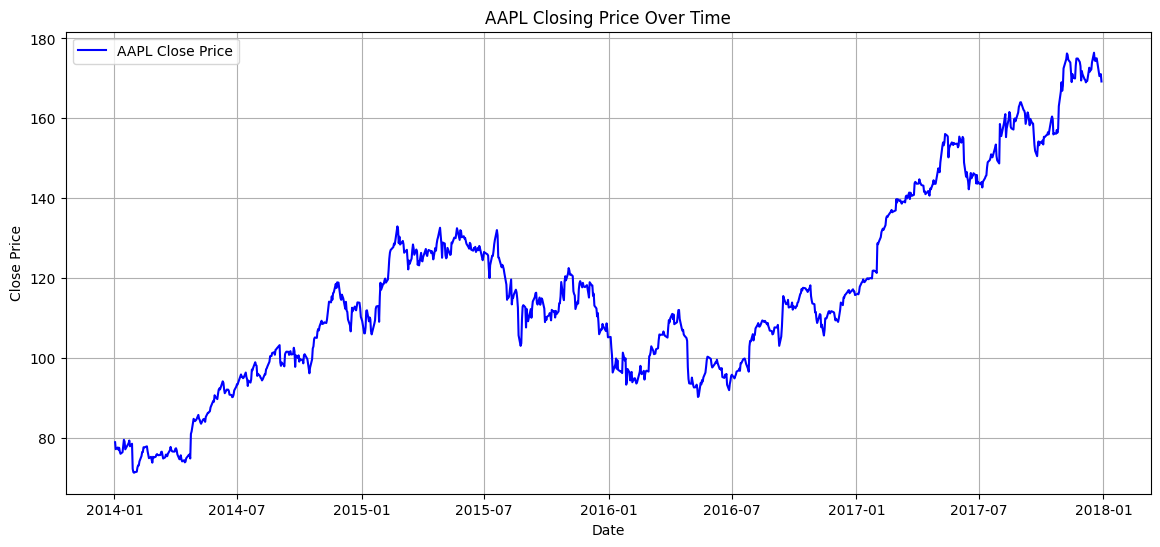

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(stock.index, stock['close'], label='AAPL Close Price', color='blue')
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

## 7️⃣ Time Series Decomposition (statsmodels)
Using **Additive Decomposition** to split the series into:

$$Y(t) = Trend(t) + Seasonal(t) + Residual(t)$$

| Component | Description |
|-----------|-------------|
| **Trend** | Long-term direction of the price |
| **Seasonal** | Repeating periodic pattern |
| **Residual** | Unexplained random noise |

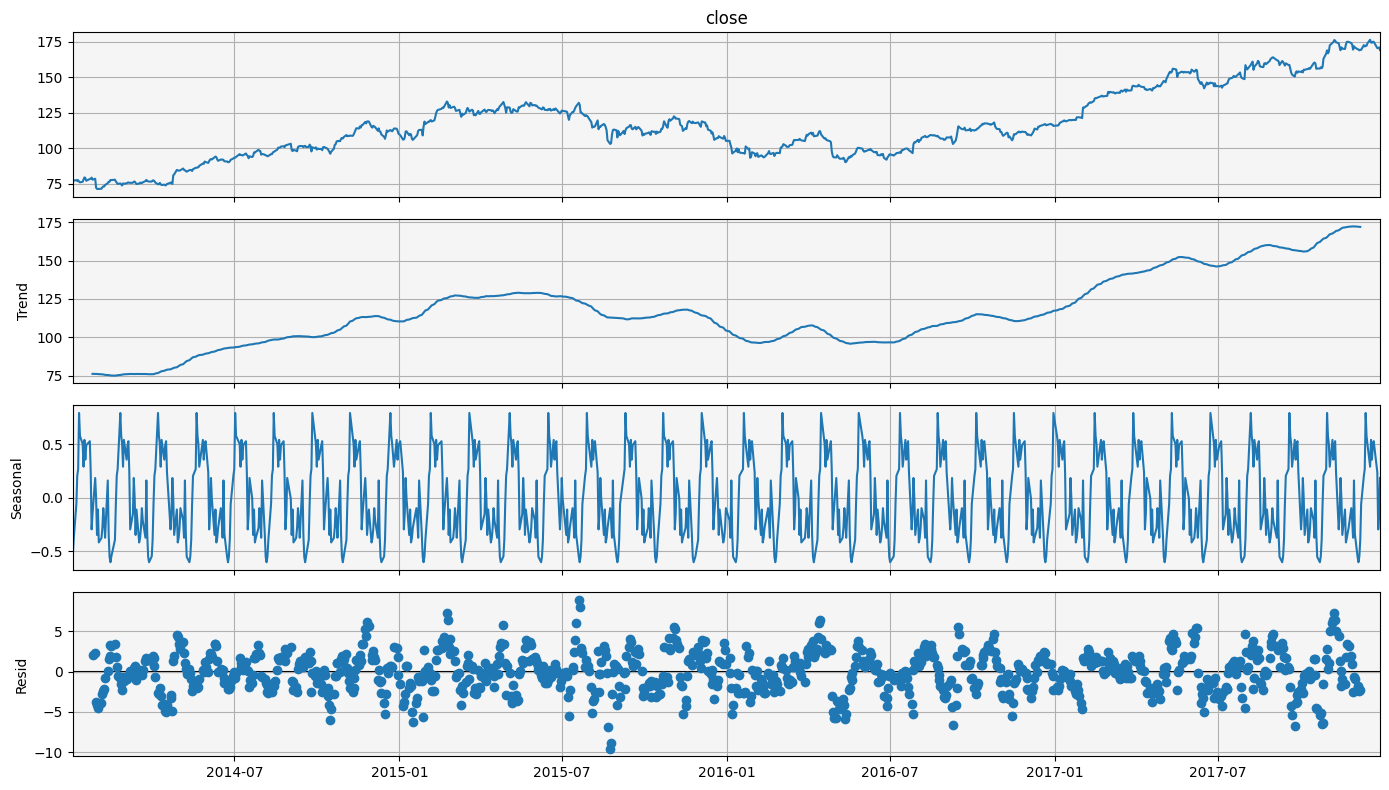

In [ ]:
result = seasonal_decompose(stock['close'], model='additive', period=30)
fig = result.plot()

fig.set_size_inches(14, 8)

plt.tight_layout()

for ax in fig.axes:
    ax.grid(True)
    ax.set_facecolor('#f5f5f5')

plt.show()

## 8️⃣ Moving Average Smoothing
Calculating **MA 20**, **MA 50**, and **MA 200** to smooth short-term noise.

In [ ]:
stock['MA_20'] = stock['close'].rolling(window=20).mean()
stock['MA_50'] = stock['close'].rolling(window=50).mean()

## 9️⃣ Plot Moving Averages
| Window | Purpose |
|--------|---------|
| **MA 20** | Short-term (monthly) trend — most sensitive |
| **MA 50** | Medium-term trend |
| **MA 200** | Long-term trend — most stable |

> 💡 When **MA 20 crosses above MA 50** → *Golden Cross* (bullish signal)  
> 💡 When **MA 20 crosses below MA 50** → *Death Cross* (bearish signal)

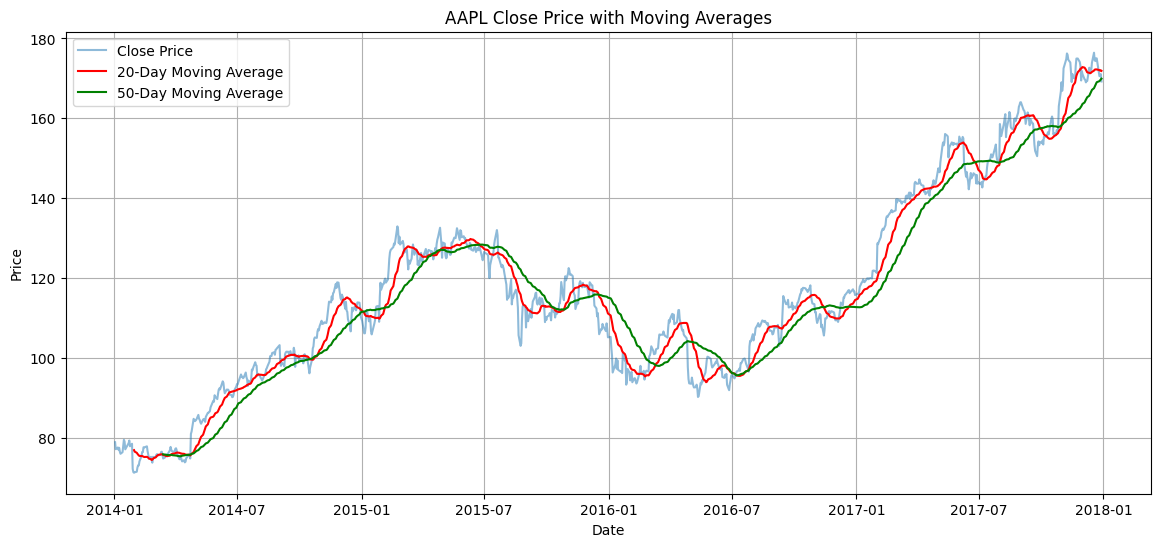

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(stock.index, stock['close'], label='Close Price', alpha=0.5)
plt.plot(stock.index, stock['MA_20'], label='20-Day Moving Average', color='red')
plt.plot(stock.index, stock['MA_50'], label='50-Day Moving Average', color='green')
plt.title('AAPL Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

---
## 🔟 Key Findings & Insights

### 📈 Trend
- The decomposition reveals the **underlying long-term direction** of AAPL's price, stripped of noise and seasonality.

### 🔁 Seasonality
- A **repeating periodic pattern** exists in the data, visible in the seasonal component plot.

### 〰️ Moving Averages
- **MA 20** reacts quickly to price changes — useful for short-term signals.
- **MA 50** smooths out weekly fluctuations — good for medium-term analysis.
- **MA 200** is the most stable line — defines the long-term bull/bear trend.

### ⚡ Residuals
- After removing trend and seasonality, residuals appear **small and random**, confirming the model captured most of the structure.

---
> **Conclusion:** The additive decomposition model fits the data well.  
> The dominant component is **Trend**, followed by **Seasonality**, with minimal unexplained noise.
